In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/caishen_bank_transactions.csv')

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df['log_amount'] = np.log1p(df["amount"]) #apply log 

In [ ]:
# did money actually transfer and was received?
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg'] # 0 if origin(sender's) balance was deducted by exactly the transfer amount?
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest'] # 0 if the destination(receiver's) balance increased by exactly the transfer amount?

In [28]:
df['errorBalanceOrig'].describe()

count    6.362620e+06
mean     2.010925e+05
std      6.066505e+05
min     -1.000000e-02
25%      2.954230e+03
50%      6.867726e+04
75%      2.496411e+05
max      9.244552e+07
Name: errorBalanceOrig, dtype: float64

In [29]:
df['errorBalanceDest'].describe()

count    6.362620e+06
mean     5.556717e+04
std      4.415288e+05
min     -7.588573e+07
25%      0.000000e+00
50%      3.500490e+03
75%      2.935305e+04
max      1.319123e+07
Name: errorBalanceDest, dtype: float64

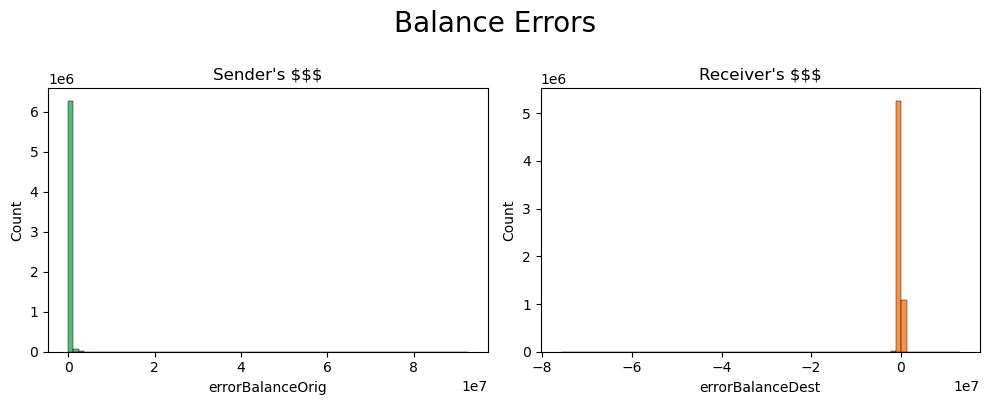

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(df['errorBalanceOrig'], ax=ax[0], bins=75, color="#19A64A")
ax[0].set_title("Sender's $$$")


sns.histplot(df['errorBalanceDest'], ax=ax[1], bins=75, color='#fa6e06')
ax[1].set_title("Receiver's $$$")


plt.suptitle('Balance Errors', y=1, fontsize=20)
plt.tight_layout()
plt.show()

############################################################ NEED TO UNDERSTAND THIS PLOT, IS IT COUNT OR THEIR MONEY? I THINK MONEY